<a href="https://colab.research.google.com/github/asavine/pub/blob/main/math-fin-course-2026/programming_assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Programming Assignment 1

Your goal is to complete this notebook, save it in Colab, and provide a link to your work. Write code in code cells, and your answers to theoretical questions in markup cells. Recall that Colab markup has support for laTex. You can write equations inline like this: $x_1 = \alpha x_2 + x_3^2$, or on display like this:
$$
  d S_t = \sigma_t d W_t^q
$$

## Delta-Hedge Backtesting and Break-Even Volatility

You will work with real-world equity data: Apple (AAPL) daily closes from 2024-09-03 to 2025-02-28, backtest the management of AAPL call options, and see for yourself how it plays out in the real world.

Data preparation is performed for you in the starter. You should pay attention, however: translating real-world data into the formal terms of the lecture is a critical and sometimes nontrivial step. Besides, setting data in the correct form may save many headaches in what follows.

In [ ]:
# AAPL data, uploaded from Google Finance

dates = np.array([
       '2024-09-03', '2024-09-04', '2024-09-05', '2024-09-06',
       '2024-09-09', '2024-09-10', '2024-09-11', '2024-09-12',
       '2024-09-13', '2024-09-16', '2024-09-17', '2024-09-18',
       '2024-09-19', '2024-09-20', '2024-09-23', '2024-09-24',
       '2024-09-25', '2024-09-26', '2024-09-27', '2024-09-30',
       '2024-10-01', '2024-10-02', '2024-10-03', '2024-10-04',
       '2024-10-07', '2024-10-08', '2024-10-09', '2024-10-10',
       '2024-10-11', '2024-10-14', '2024-10-15', '2024-10-16',
       '2024-10-17', '2024-10-18', '2024-10-21', '2024-10-22',
       '2024-10-23', '2024-10-24', '2024-10-25', '2024-10-28',
       '2024-10-29', '2024-10-30', '2024-10-31', '2024-11-01',
       '2024-11-04', '2024-11-05', '2024-11-06', '2024-11-07',
       '2024-11-08', '2024-11-11', '2024-11-12', '2024-11-13',
       '2024-11-14', '2024-11-15', '2024-11-18', '2024-11-19',
       '2024-11-20', '2024-11-21', '2024-11-22', '2024-11-25',
       '2024-11-26', '2024-11-27', '2024-11-29', '2024-12-02',
       '2024-12-03', '2024-12-04', '2024-12-05', '2024-12-06',
       '2024-12-09', '2024-12-10', '2024-12-11', '2024-12-12',
       '2024-12-13', '2024-12-16', '2024-12-17', '2024-12-18',
       '2024-12-19', '2024-12-20', '2024-12-23', '2024-12-24',
       '2024-12-26', '2024-12-27', '2024-12-30', '2024-12-31',
       '2025-01-02', '2025-01-03', '2025-01-06', '2025-01-07',
       '2025-01-08', '2025-01-10', '2025-01-13', '2025-01-14',
       '2025-01-15', '2025-01-16', '2025-01-17', '2025-01-21',
       '2025-01-22', '2025-01-23', '2025-01-24', '2025-01-27',
       '2025-01-28', '2025-01-29', '2025-01-30', '2025-01-31',
       '2025-02-03', '2025-02-04', '2025-02-05', '2025-02-06',
       '2025-02-07', '2025-02-10', '2025-02-11', '2025-02-12',
       '2025-02-13', '2025-02-14', '2025-02-18', '2025-02-19',
       '2025-02-20', '2025-02-21', '2025-02-24', '2025-02-25',
       '2025-02-26', '2025-02-27', '2025-02-28', '2025-03-03'])

aapl = np.array([222.77, 220.85, 222.38, 220.82, 220.91, 220.11, 222.66, 222.77,
       222.5 , 216.32, 216.79, 220.69, 228.87, 228.2 , 226.47, 227.37,
       226.37, 227.52, 227.79, 233.  , 226.21, 226.78, 225.67, 226.8 ,
       221.69, 225.77, 229.54, 229.04, 227.55, 231.3 , 233.85, 231.78,
       232.15, 235.  , 236.48, 235.86, 230.76, 230.57, 231.41, 233.4 ,
       233.67, 230.1 , 225.91, 222.91, 222.01, 223.45, 222.72, 227.48,
       226.96, 224.23, 224.23, 225.12, 228.22, 225.  , 228.02, 228.28,
       229.  , 228.52, 229.87, 232.87, 235.06, 234.93, 237.33, 239.59,
       242.65, 243.01, 243.04, 242.84, 246.75, 247.77, 246.49, 247.96,
       248.13, 251.04, 253.48, 248.05, 249.79, 254.49, 255.27, 258.2 ,
       259.02, 255.59, 252.2 , 250.42, 243.85, 243.36, 245.  , 242.21,
       242.7 , 236.85, 234.4 , 233.28, 237.87, 228.26, 229.98, 222.64,
       223.83, 223.66, 222.78, 229.86, 238.26, 239.36, 237.59, 236.  ,
       228.01, 232.8 , 232.47, 233.22, 227.63, 227.65, 232.62, 236.87,
       241.53, 244.6 , 244.47, 244.87, 245.83, 245.55, 247.1 , 247.04,
       240.36, 237.3 , 241.84, 243.71])

In [ ]:
# put series in a pandas dataframe
df = pd.DataFrame(aapl, pd.to_datetime(dates), columns = ["St"])
df.index.name = "date"

In [ ]:
df

,St
date,
2024-09-03,222.77
2024-09-04,220.85
2024-09-05,222.38
2024-09-06,220.82
2024-09-09,220.91
...,...
2025-02-25,247.04
2025-02-26,240.36
2025-02-27,237.30


In [ ]:
# set the mid-point as the origin of time
# first half is "historical" data, second half is "future" data
origin_index = len(df) // 2
origin = df.iloc[origin_index]
origin_date = origin.name
origin_index, origin_date, origin

(62,
 Timestamp('2024-11-29 00:00:00'),
 St    237.33
 Name: 2024-11-29 00:00:00, dtype: float64)

In [ ]:
# now we have an origin, we can label data by time (in years)
df["t"] = (df.index.to_series() - origin_date).dt.days / 365
df

,St,t
date,,
2024-09-03,222.77,-0.238356
2024-09-04,220.85,-0.235616
2024-09-05,222.38,-0.232877
2024-09-06,220.82,-0.230137
2024-09-09,220.91,-0.221918
...,...,...
2025-02-25,247.04,0.241096
2025-02-26,240.36,0.243836
2025-02-27,237.30,0.246575


In [ ]:
# in order to facilitate the assignment, we also compute first differences and time steps
df["dSt"] = - df["St"].diff(periods=-1) # dSt[n] = St[n+1] - St[n]
df["dt"] = - df["t"].diff(periods=-1) # dt[n] = t[n+1] - t[n]
df

,St,t,dSt,dt
date,,,,
2024-09-03,222.77,-0.238356,-1.92,0.002740
2024-09-04,220.85,-0.235616,1.53,0.002740
2024-09-05,222.38,-0.232877,-1.56,0.002740
2024-09-06,220.82,-0.230137,0.09,0.008219
2024-09-09,220.91,-0.221918,-0.80,0.002740
...,...,...,...,...
2025-02-25,247.04,0.241096,-6.68,0.002740
2025-02-26,240.36,0.243836,-3.06,0.002740
2025-02-27,237.30,0.246575,4.54,0.002740


In [ ]:
# we no longer need dates, reindex and we can rearrange columns
df = df.set_index('t')[['dt', "St", 'dSt']]
df

,dt,St,dSt
t,,,
-0.238356,0.002740,222.77,-1.92
-0.235616,0.002740,220.85,1.53
-0.232877,0.002740,222.38,-1.56
-0.230137,0.008219,220.82,0.09
-0.221918,0.002740,220.91,-0.80
...,...,...,...
0.241096,0.002740,247.04,-6.68
0.243836,0.002740,240.36,-3.06
0.246575,0.002740,237.30,4.54


In [ ]:
# this may help
past_data = df.loc[df.index<=0]
future_data = df.loc[df.index>=0]

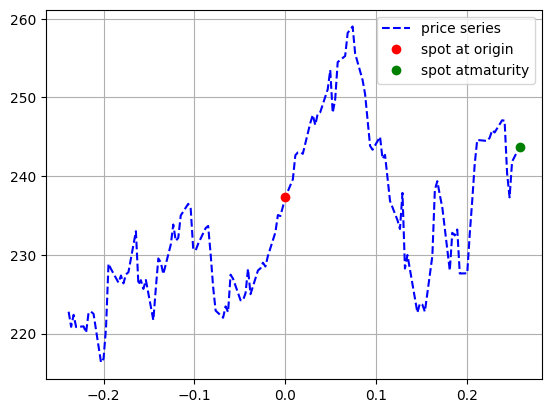

In [ ]:
plt.plot(df.index, df['St'], 'b--', label="price series")
plt.plot([0], df.loc[0].St, 'ro', label="spot at origin")
plt.plot([df.index[-1]], df.iloc[-1].St, 'go', label="spot atmaturity")
plt.grid()
plt.legend()

Now comes the assignment.

# Question 1
Code Black and Scholes formulas for price, delta, gamma and vega. The signature of the functions should be:

<center>
  t, St, vol, K, T -> price or Greeks
</center>

Convention for equity derivatives is usually Black and Scholes and lognormal volatility. Note that equity prices are positive underlying assets.

Test your functions: for spot 100, strike 110, maturity 2 years, volatility 20%, you should obtain a price around 7.47, delta around 42%, gamma around 1.4% and vega around 55.

Solution:

In [ ]:
from scipy.stats import norm

def bs_price(t, St, vol, K, T):
  # your code here
  pass

def bs_delta(t, St, vol, K, T):
  # your code here
  pass

def bs_gamma(t, St, vol, K, T):
  # your code here
  pass

def bs_vega(t, St, vol, K, T):
  # your code here
  pass

In [ ]:
bs_price(0, 100, .2, 110, 2), bs_delta(0, 100, .2, 110, 2), bs_gamma(0, 100, .2, 110, 2), bs_vega(0, 100, .2, 110, 2)

(np.float64(7.467730366014848),
 np.float64(0.42248080172878816),
 np.float64(0.01383761739745125),
 np.float64(55.35046958980502))

# Question 2

Estimate historical (lognormal) volatility on past data. A correct estimation should give a result between 20% and 21%.

Then, estimate volatility on *future* data. Is the first estimate a decent predictor of future volatility? What should we expect when using the past predictor to manage options on future data? Compute the expected PnL for the strike 230, maturiting on the last day of future data.

The result should be around 2.3.

Solution:

In [ ]:
def estimate_volatility(data):
  # your code here
  pass


In [ ]:
past_vol = estimate_volatility(past_data)
past_vol

0.2063784683871526

In [ ]:
future_vol = estimate_volatility(future_data)
future_vol

0.25685884893555627

The historical estimate crudely underestimates future volatility (21 vs 26), highlighting the non-stationary nature of financial data. This is why forward-looking, market-implied parameters, obtained by calibration to market prices, are generally preferred.

Since realised volatility is 5 points above implied, we expect to make 5 vegas:

In [ ]:
# alternatively, price(future_vol) - price(past_vol)
t = 0
St = future_data.iloc[0].St
vol = past_vol
strike = 230
expiry = future_data.index[-1]

vega = bs_vega(t, St, vol, strike, expiry)

expected_pnl = (future_vol - past_vol) * vega
expected_pnl

np.float64(2.2798735400276735)

# Question 3

You will now backtest the delta-hedge of this option (on future data) and compute the actual, realized PnL. Use an implied volatility of 20.50% across the period.

Use the future_data frame, the signature of your function should be:

<center>
  data, strike, implied vol -> PnL
</center>

The function may assume that the first line of data is the initial market state, when the option is purchased, and the last line is the market state on expiry, which determines the payoff of the option.

You should find something around 3.2.

Recall the prediction made in the previous question, based on a volatility estimate *on future data*, was around 2.3, missing the target by 0.9, or 40%!

Using the idioms taught in class, explain why this should not be surprising.

Solution:

In [ ]:
def backtest_pnl_actual(data, strike, implied_vol):
  # your code here
  pass


In [ ]:
backtest_pnl_actual(future_data, strike, 0.205)

np.float64(3.2324233520829253)

There are two reasons why the naive formula $PnL \approx BS(\sigma_r) - BS(\hat \sigma) \approx vega(\hat\sigma) * (\sigma_r - \hat\sigma)$ is such a poor predictor of what happens when you hedge with the wrong volatility in the real world.

First is PnL *variance* due to random gamma weighting. Even if the real-world price series were a realization of a Geometric Brownian Motion with some volatility $\sigma_r$, it would not follow that the realized PnL of a delta-hedge with a different volatility $\hat \sigma$ would produce a PnL of $BS(\sigma_r) - BS(\hat \sigma)$.

What *is* true (under this GBM assumption) if that hedging with the *correct* volatility does produce a PnL of 0 with probabilty 1 (in the limit of a continuous hedge). But when you hedge with the wrong volatility, your delta is incorrect, and your PnL is no longer constant.

Even in the limit of a continuous hedge, PnL remains random, with expectation $BS(\sigma_r) - BS(\hat \sigma)$, yes, but also, considerable variance. Realized PnL may land far from expectation.

Second reason is that the real world does not satisfy Black and Scholes' assumption of a constant volatility to start with. In reality, the magnitude of price oscillations is highly non-stationary and fluctuates across the hedging period.

The conventional variance estimate $\overline {(R_i-\overline R)^2}$, where $R_i = (S_{i+1}-S_i)/(S_i \sqrt{T_{i+1}-T_i})$, is a *uniform* average of the centered square returns.

We have seen in class that what matters for PnL is the average, *weighted by gamma*. Gamma is maximum around the money, when the spot hovers around the strike, and decreases exponentially out-of-the-money. Besides, gamma becomes taller and narrower as time to maturity shrinks, converging towards a Dirac delta on the strike at maturity.

It follows that the uniform and weighted averages may realize very differently, when the magnitude of delivered returns is different around or far from the strike, and near or far from expiry. Therefore, the standard, uniform estimate of volatility is a poor predictor of realised PnL.

In what follows, we develop the alternative "break-even" estimator, which directly estimates volatility from PnL considerations.

# Question 4
Compute the theoretical PnL as taught in class, and verify that it is close to actual. Cite two reasons why numbers might differ, and what could be done, if anything, to remedy discrepancies in a real trading situation.

Solution: recall from class that theoretical daily PnL is given by:
$$
  \frac{1}{2} \Gamma [(\Delta S)^2 - (\hat \sigma S)^2 \Delta_t]
$$
and cumulated PnL is the sum of daily PnLs.

Solution:

In [ ]:
def backtest_pnl_theoretical(data, strike, implied_vol):
  # your code here
  pass


In [ ]:
backtest_pnl_theoretical(future_data, 230, 0.205)

np.float64(3.067645682346017)

Theoretical PnL is decently close to realized: 3.07 vs 3.23. Recall that the theoretical PnL formula was derived from a second-order expansion. There may be two sources of discrepancy:

1.   Daily time step is too wide so that second-order expansion fails to make an accurate prediction. This is probably the reason for the discrepancy we are seeing. It can be remedied by increasing hedge frequency: hedge twice daily, or more for very volatile price series. One of the exercises explores the idea of rehedging every $\Delta S$ as opposed to every $\Delta t$. Unfortunately, you need high-frequency intraday data to backtest it.

  As long as price series is continuous, theoretical and realized PnL must converge in the limit of a small time step. Unfortunately, we don't have intraday data to illustrate this statement.

  In the interest of intellectual closure, you can do the following: add the 3rd order term in the daily PnL formula, and verify that realized PnL predicts actual to the second decimal. We know that the 3rd order term will vanish as $\Delta t$ shrinks, as long as price series remain continuous. The formula for the 3rd order derivative, sometimes called "speed", is found on Wikipedia: https://en.wikipedia.org/wiki/Greeks_(finance)

2.   We have discontinuities in the price series. Recall that continuous price series is a fundamental assumption made in class. Discontinuities the classic theory. Nothing can be done to reconciliate the two: however frequently you rehedge around a discontinuity, the second-order expansion will not converge, as higher-order terms never vanish. There is no evident discontinuities in our data, but it cannot be confirmed without high-frequency data (and even so, not trivially).



# Question 5

Use a root-finding algorithm of your choice to find the unique volatility that sets PnL to 0.

**What you just did is find an alternative estimate of volatility via delta-hedge back-testing. This way of estimating volatility was first found by Dupire, and named "break-even volatility". Note that break-even volatility is linked to a given strike and maturity, contrarily to the conventional estimate.**

Solution:

In [ ]:
from scipy.optimize import root_scalar

def break_even_vol(data, strike):
  # your code here
  pass


In [ ]:
vol = break_even_vol(future_data, 230)
vol

0.2568519937432901

In [ ]:
# sanity check
backtest_pnl_actual(future_data, 230, vol)

np.float64(-4.973799150320701e-14)

# Question 6

Estimate break-even volatility for strikes 200 to 300, every 5. Show your results in a dataframe and a chart.

(If your numerical algorithm fails to find the root far from the money, understand why and adjust your algorithm parameters accordingly)

What do you observe? Explain your results using the idioms taught in class. What phenomenon do you believe the break-even estimate picked-up in the data that the conventional estimate did not? How does your experiment justify the existence of a market implied volatility smile?

**Your experiment accounts for one justification of volatility smiles. Which one?
There are other justifications, such as discontinuities and stochastic volatility, not covered in class and not caught by the break-even volatility estimate.**

Solution:

In [ ]:
  # your code here
  break_even_vols = None


In [ ]:
break_even_vols

,actual
200.0,0.250833
205.0,0.256562
210.0,0.260416
215.0,0.262396
220.0,0.262281
225.0,0.260165
230.0,0.256852
235.0,0.251617
240.0,0.237964
245.0,0.218395


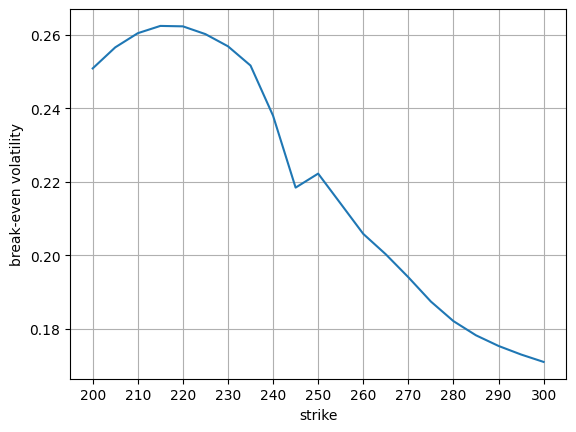

In [ ]:
break_even_vols.plot()
plt.xticks(np.linspace(200, 300, 11))
plt.xlabel("strike")
plt.ylabel("break-even volatility")
plt.grid()

We observe that break-even estimates sharply vary by strike, in a generally decreasing shape, around 26% for low strikes around 220, down to 18% for high strikes around 280. We also observe a kink around strike 245.

For strike 230, PnL was zeroed with a management volatility of 25.7%. For strike 260, it was 20.6%. The same volatility that zeroes PnL for strike 260 produces a significant profit (expected 5 vegas) for strike 230!  

PnL for a given strike is mainly sensitive to realized volatility when gamma is large, that is, when prices hover around the strike. Strike 230 mainly captured the magnitude of realized osciliations when prices were around 230, around $t=0.15$ in our data. Strike 260 mainly captured fluctuations when prices were around 260, around $t=0.05$. It is worth having another look at the price data chart.

Therefore, the break-even estimate picks-up *local volatility*: AAPL was more volatile around $t=0.05$ when the stock hovered around 260, and less volatile around $t=0.15$ with prices around $230$. We have seen in class that local volatility produces an implied volatility smile, where implied volatilities are quadratic averages of local volatilities, around the line the joins the spot price today to the strike at expiry. Break-even estimates pick-up local volatility, whereas conventional volatility estimates average it out.

Assuming local volatility (how volatility depends on spot price) persists in the future, break-even estimates therefore provide fair and different volatility quotes per strike, thereby justifying implied volatility smiles.

The kink on strike 245 is due to the extreme sensitivity of PnL to the volatility realized very near the strike at maturity, when gamma converges to a Dirac delta. With a final fixing around 244 in our data, the last few days affect strike 245 in a major manner, and not at all the other strikes. Break-even estimates will often have a kink around the final asset price. This is an undesirable artefact of the method, usually smoothed out in parctice by a veriety of means.

# Question 7

Use theoretical PnL to find an exact implicit formula for the break-even estimate. What do you observe?

Find an explicit approximation and compare results with the results of question 6.

Bonus: try to improve the approximation.

Soution:

We have seen that theoretical PnL is:
$$
  \sum_i \frac{1}{2} \Gamma(S_i, t_i; K, T; \hat \sigma) S_i^2 [(\frac{\Delta S_i}{S_i \sqrt{{\Delta_t}_i}})^2 - \hat \sigma ^2 ] {\Delta_t}_i
$$

Setting it to 0 gives the formula:
$$
  \hat \sigma^2 = \frac{\sum_i \Gamma(S_i, t_i; K, T; \hat \sigma) S_i^2 (\frac{\Delta S_i}{S_i \sqrt{{\Delta_t}_i}})^2 {\Delta_t}_i}{\sum_i \Gamma(S_i, t_i; K, T; \hat \sigma) S_i^2 {\Delta_t}_i}
$$

This is an implicit formula, because $\hat \sigma$ appears on both sides. On the right-hand side, it is used to compute gammas for weighting. Noting that, since only relative weights count, we may approximate the formula by using, instead, the conventional estimate of volatility (denote it $\widetilde \sigma$, recall it is around 25.5%) to compute gammas. This gives an explicit approximation, which is no longer exact, but does away with numerical root finding:

$$
  \hat \sigma^2 \approx \frac{\sum_i \Gamma(S_i, t_i; K, T; \widetilde \sigma) S_i^2 (\frac{\Delta S_i}{S_i \sqrt{{\Delta_t}_i}})^2 {\Delta_t}_i}{\sum_i \Gamma(S_i, t_i; K, T; \widetilde \sigma) S_i^2 {\Delta_t}_i}
$$






In [ ]:
def break_even_vol_approx(data, strike, approx_vol):
  # your code here
  pass

In [ ]:
vols = [break_even_vol_approx(future_data, strike, future_vol) for strike in strikes]
break_even_vols_approx = pd.Series(vols, index=strikes, name="approx")
break_even_df = pd.concat([break_even_vols, break_even_vols_approx], axis=1)
break_even_df

,actual,approx
200.0,0.250833,0.250359
205.0,0.256562,0.256097
210.0,0.260416,0.260033
215.0,0.262396,0.261955
220.0,0.262281,0.261497
225.0,0.260165,0.258567
230.0,0.256852,0.253042
235.0,0.251617,0.243586
240.0,0.237964,0.233056
245.0,0.218395,0.228024


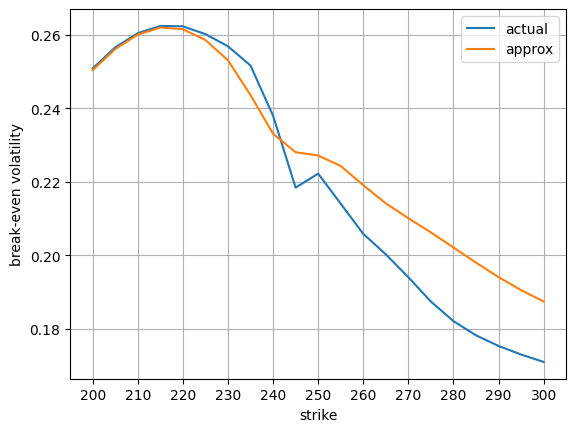

In [ ]:
break_even_df.plot()
plt.xticks(np.linspace(200, 300, 11))
plt.xlabel("strike")
plt.ylabel("break-even volatility")
plt.grid()
plt.legend()

Unsurprisingly, the approximation holds its ground for low strikes, where the result is close to the proxy, but breaks for high strikes, where the result is far from proxy. However, the approximation correctly estimates the shape of break-even function of strike, which is encouraging.
We can improve by recursion, using the result as the next proxy, thereby implementing a *fixed-point* algorithm:

In [ ]:
def break_even_vol_approx2(data, strike, approx_vol, num_recurse=5):
  for _ in range(num_recurse):
    approx_vol = break_even_vol_approx(data, strike, approx_vol)
  return approx_vol

In [ ]:
vols = [break_even_vol_approx2(future_data, strike, future_vol) for strike in strikes]
break_even_vols_approx2 = pd.Series(vols, index=strikes, name="approx2")
break_even_df = pd.concat([break_even_df, break_even_vols_approx2], axis=1)
break_even_df

,actual,approx,approx2
200.0,0.250833,0.250359,0.249891
205.0,0.256562,0.256097,0.256083
210.0,0.260416,0.260033,0.259958
215.0,0.262396,0.261955,0.261654
220.0,0.262281,0.261497,0.261098
225.0,0.260165,0.258567,0.258401
230.0,0.256852,0.253042,0.253410
235.0,0.251617,0.243586,0.244445
240.0,0.237964,0.233056,0.232461
245.0,0.218395,0.228024,0.225934


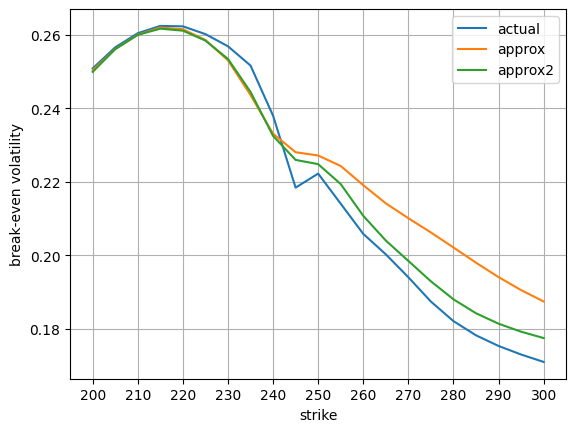

In [ ]:
break_even_df.plot()
plt.xticks(np.linspace(200, 300, 11))
plt.xlabel("strike")
plt.ylabel("break-even volatility")
plt.grid()
plt.legend()

We get a much better approximation, where the remaining discrepancy is only due to the previously observed difference between theoretical and actual PnL, due to that daily hedge is too sporadic for accurate PnL explain.

Next, compare the (exact) formula with the expression for the lognormal implied volatility function of local volatility seen in class (more precisely: the lognormal variant, immediately deduced from the normal variant seen in class):

$$
        \hat \sigma_L^2 = \frac{E^{Q(LV)} [\int_0^T \Gamma_{BS}(S_t, t; K, T; \hat \sigma_L) S_t^2 \sigma^2(S_t, t) dt]}{E^{Q(LV)} [\int_0^T \Gamma_{BS}(S_t, t; K, T; \hat \sigma_L) S_t^2 dt]}
$$

We can see that it is essentially the same formula, modulo:


1.   (Andecdotically) the break-even formula is a discrete version of the theoretical integral

2.   *Importantly*, the theoretical expectations (across possible paths for $(S_t)$) are replaced by realised values in the data

This confirms that the break-even volatility estimate is, indeed, a local volatility estimate in disguise, as hinted in our comments in the previous question.

But this estimate is extremely crude, with averages over all possible paths are replaced by the one path present in the data. This comment resonates with some previous comments we made, about overreliance on realized data, in particular, spot prices in the final days, when gamma converges towards a Dirac delta. In machine learning parlance, this is a form of overfitting.


# Question 8

Suppose now that a trader sitting at time 0 uses past data to estimate break-even volaitlity for strikes 200 to 300, and uses these estimates to quote, and manage, options maturing on the last date of future data.

Compute their realized PnL by strike, translate it in units of vega, and conclude.

Solution:

           past    future
200.0  0.216723  0.250833
205.0  0.212834  0.256562
210.0  0.208247  0.260416
215.0  0.203095  0.262396
220.0  0.197533  0.262281
225.0  0.191909  0.260165
230.0  0.186581  0.256852
235.0  0.180616  0.251617
240.0  0.185498  0.237964
245.0  0.200048  0.218395
250.0  0.204910  0.222206
255.0  0.206748  0.214021
260.0  0.207754  0.205809
265.0  0.208656  0.200247
270.0  0.209648  0.194008
275.0  0.210726  0.187390
280.0  0.211815  0.182069
285.0  0.212820  0.178205
290.0  0.213647  0.175310
295.0  0.214207  0.172977
300.0  0.214426  0.170961


Text(0, 0.5, 'break-even volatility')

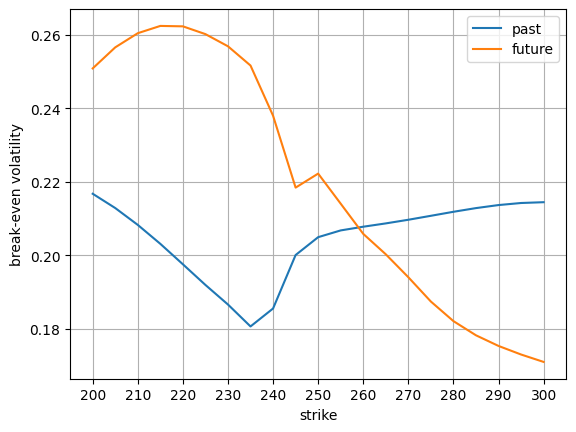

In [ ]:
# compute break-even vols on past data and compare with the ones we computed on future data
strikes = np.linspace(200,300,21)

past_break_even = [break_even_vol(past_data, strike) for strike in strikes]
# we already computed those, recompute here
future_break_even = [break_even_vol(future_data, strike) for strike in strikes]

df = pd.DataFrame(data={"past": past_break_even, "future": future_break_even}, index=strikes)
print(df)
df.plot(legend=True, grid=True)
plt.xticks(np.linspace(200, 300, 11))
plt.xlabel("strike")
plt.ylabel("break-even volatility")

We get very different results, both in magbnitude and shape.

In [ ]:
# sanity check
[backtest_pnl_actual(past_data, strike, vol) for (strike, vol) in zip(strikes, past_break_even)]

[np.float64(5.336175945558352e-12),
 np.float64(7.887024366937112e-13),
 np.float64(1.9895196601282805e-13),
 np.float64(-1.4210854715202004e-14),
 np.float64(-2.4868995751603507e-14),
 np.float64(-1.0658141036401503e-14),
 np.float64(4.440892098500626e-15),
 np.float64(1.9539925233402755e-14),
 np.float64(1.6431300764452317e-14),
 np.float64(-1.3322676295501878e-15),
 np.float64(1.7763568394002505e-15),
 np.float64(4.0190073491430667e-14),
 np.float64(-7.66053886991358e-15),
 np.float64(-7.771561172376096e-16),
 np.float64(7.734923812563466e-13),
 np.float64(1.3239409568654992e-14),
 np.float64(3.2751579226442118e-15),
 np.float64(2.5493496202955157e-14),
 np.float64(6.987466161234579e-15),
 np.float64(8.326672684688674e-17),
 np.float64(1.0234868508263162e-13)]

            pnl
200.0  0.176097
205.0  0.413682
210.0  0.838554
215.0  1.511526
220.0  2.437855
225.0  3.489075
230.0  4.450235
235.0  5.350741
240.0  4.394680
245.0  1.349404
250.0  0.883940
255.0  0.248935
260.0 -0.048900
265.0 -0.159618
270.0 -0.224354
275.0 -0.263414
280.0 -0.272370
285.0 -0.255946
290.0 -0.223734
295.0 -0.184550
300.0 -0.144715


Text(0, 0.5, 'pnl')

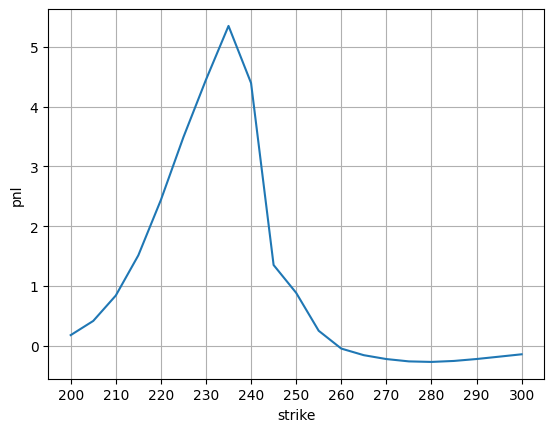

In [ ]:
# so using past estimates on past data gives us 0 PnL as expected
# what about future data?
future_pnl = [backtest_pnl_actual(future_data, strike, vol) for (strike, vol) in zip(strikes, past_break_even)]
df = pd.DataFrame(data={"pnl": future_pnl}, index=strikes)
print(df)
df.plot(legend=False, grid=True)
plt.xticks(np.linspace(200, 300, 11))
plt.xlabel("strike")
plt.ylabel("pnl")

Text(0.5, 0, 'strike')

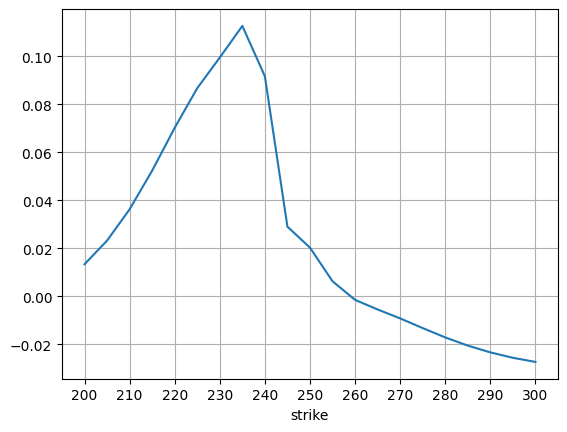

In [ ]:
# this looks really terrible, and of course, the pnl is highest at-the-money, where vega, which measures dependence to volatility, is highest
# translate in vega units
df["vega"] = [bs_vega(0, future_data.St.iloc[0], vol, strike, future_data.index[-1]) for (strike, vol) in zip(strikes, past_break_even)]
df["pnl in vega"] = df.pnl / df.vega

df["pnl in vega"].plot(legend=False, grid=True)
plt.xticks(np.linspace(200, 300, 11))
plt.xlabel("strike")

PnL is horribly wrong, up to 10+ vega discrepancy!

It is worth, once again, having another look at the chart of the price series. Non-stationarity is visible by the naked eye. The first half is characterized by tight range trading with little volatility, the second half features successive breakouts with high volatility.

We have already seen in question 2 that overall volatility was 5 points higher in the second half. We are now seeing that it is not only the overall volatility that changed, but the whole *local volatility structure*.

Non-stationarity and changes of regime are very frequent in finance. Using historical estimates for trading may be ineffective and dangerous. Derivatives professionals always prefer reading *forward looking estimates* implied by market prices. The volatility implied in the market price of a traded options is much more reliable than a historical estimate based on past data. Similarly, the local volatility implied from the market volatility smile, using Dupire's formula, is a much better estimate of future behaviour than break-even volatility.

Although traders go to great lengths to try to imply volatility from forward-looking market data, historical estimates are not completely useless, especially in situations where there is no market data to imply from. Notice that we used very little data in out analysis: 3 months past + 3 months future. Of course, overfitting should be expected in this situation. With a much larger amount of data, correctly leveraged with overfitting-mitigating algorithms, we could have produced more useful results.